# Insurance Claims - Exploratory Data Analysis
## Understanding the Data and Problem Space

**Author:** Nandeesh H S  
**Project:** Insurance Risk Analytics & Claims Prediction

---

### Objectives
1. Load and understand the insurance claims dataset
2. Analyze target variables (CS, LC, HALC)
3. Explore feature distributions and relationships
4. Identify data quality issues
5. Generate insights for feature engineering

In [1]:
# Import libraries
import sys
from pathlib import Path

# Add src to path
sys.path.append(str(Path('..').resolve() / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [2]:
from data_loader import DataLoader, create_target_variables

# Load data
loader = DataLoader()
train_df, test_df = loader.load_data()

# Create target variables
train_df = create_target_variables(train_df)

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nColumns: {len(train_df.columns)}")

INFO:data_loader:Loading datasets...


INFO:data_loader:Training data loaded: (37451, 28)


INFO:data_loader:Test data loaded: (15787, 23)


INFO:data_loader:Validating data quality...


INFO:data_loader:Data validation complete


INFO:data_loader:Target variables created successfully


INFO:data_loader:Claim rate: 11.08%


Training data shape: (37451, 31)
Test data shape: (15787, 23)

Columns: 31


## 2. Target Variable Analysis

### 2.1 Claim Status (CS) - Binary Classification

Claim Rate: 11.08%
No Claims: 33,300 (88.92%)
Claims: 4,151 (11.08%)


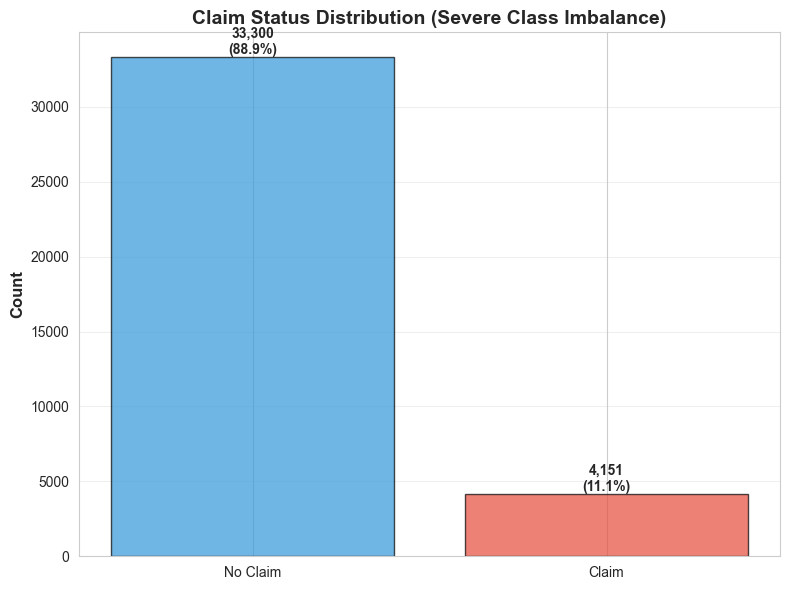


[INSIGHT] Severe class imbalance (~89% no claims) - requires appropriate modeling techniques


In [3]:
# Claim rate analysis
claim_rate = train_df['CS'].mean()
print(f"Claim Rate: {claim_rate*100:.2f}%")
print(f"No Claims: {(train_df['CS']==0).sum():,} ({(1-claim_rate)*100:.2f}%)")
print(f"Claims: {(train_df['CS']==1).sum():,} ({claim_rate*100:.2f}%)")

# Visualize class imbalance
fig, ax = plt.subplots(figsize=(8, 6))
cs_counts = train_df['CS'].value_counts()
colors = ['#3498db', '#e74c3c']
ax.bar(['No Claim', 'Claim'], cs_counts, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Claim Status Distribution (Severe Class Imbalance)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(cs_counts):
    ax.text(i, v, f'{v:,}\n({v/len(train_df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[INSIGHT] Severe class imbalance (~89% no claims) - requires appropriate modeling techniques")

### 2.2 Loss Cost (LC) - Zero-Inflated Continuous Target

Loss Cost (LC) Statistics:
Mean: 69.81
Median: 0.00
Std Dev: 838.66
Min: 0.00
Max: 118142.59

Zeros: 33,300 (88.92%)
Non-Zeros: 4,151 (11.08%)


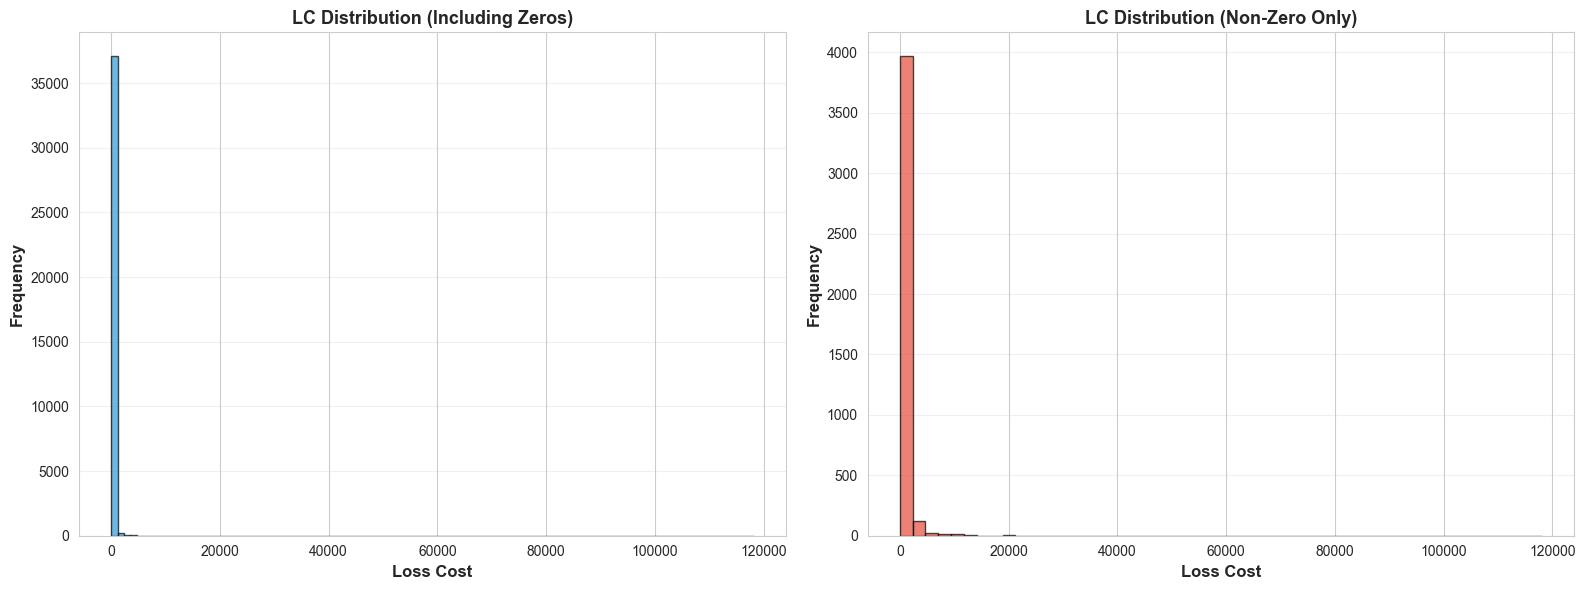


[INSIGHT] Zero-inflated distribution - Tweedie regression is ideal for this problem!


In [4]:
# LC statistics
print("Loss Cost (LC) Statistics:")
print(f"Mean: {train_df['LC'].mean():.2f}")
print(f"Median: {train_df['LC'].median():.2f}")
print(f"Std Dev: {train_df['LC'].std():.2f}")
print(f"Min: {train_df['LC'].min():.2f}")
print(f"Max: {train_df['LC'].max():.2f}")
print(f"\nZeros: {(train_df['LC']==0).sum():,} ({(train_df['LC']==0).mean()*100:.2f}%)")
print(f"Non-Zeros: {(train_df['LC']>0).sum():,} ({(train_df['LC']>0).mean()*100:.2f}%)")

# Visualize LC distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All values
axes[0].hist(train_df['LC'], bins=100, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Loss Cost', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('LC Distribution (Including Zeros)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Non-zero values
lc_nonzero = train_df[train_df['LC'] > 0]['LC']
axes[1].hist(lc_nonzero, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Loss Cost', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('LC Distribution (Non-Zero Only)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n[INSIGHT] Zero-inflated distribution - Tweedie regression is ideal for this problem!")

### 2.3 HALC - Historically Adjusted Loss Cost

HALC Statistics:
Mean: 128.15
Median: 0.00
Correlation with LC: 0.9385


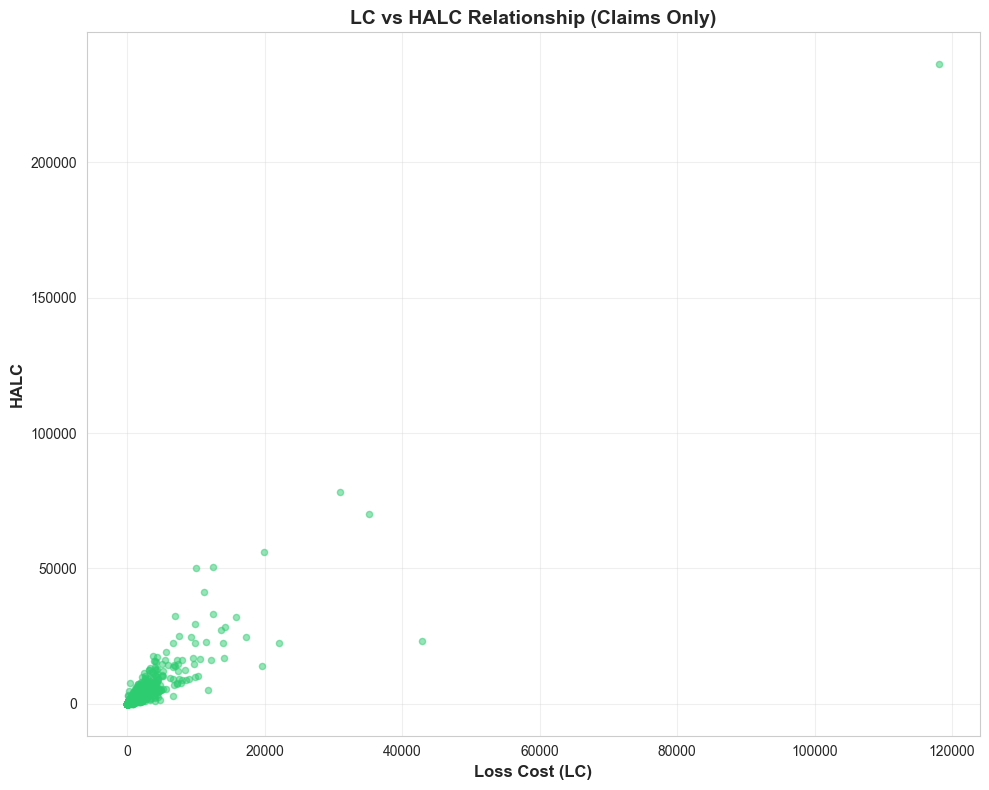

In [5]:
# HALC statistics
print("HALC Statistics:")
print(f"Mean: {train_df['HALC'].mean():.2f}")
print(f"Median: {train_df['HALC'].median():.2f}")
print(f"Correlation with LC: {train_df[['LC', 'HALC']].corr().iloc[0,1]:.4f}")

# Visualize LC vs HALC
fig, ax = plt.subplots(figsize=(10, 8))
claims_data = train_df[train_df['CS'] == 1]
ax.scatter(claims_data['LC'], claims_data['HALC'], alpha=0.5, s=20, color='#2ecc71')
ax.set_xlabel('Loss Cost (LC)', fontsize=12, fontweight='bold')
ax.set_ylabel('HALC', fontsize=12, fontweight='bold')
ax.set_title('LC vs HALC Relationship (Claims Only)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Feature Analysis

### 3.1 Numerical Features

Numerical features: 17
['X.7', 'X.8', 'X.9', 'X.10', 'X.11', 'X.12', 'X.13', 'X.14', 'X.19', 'X.20']


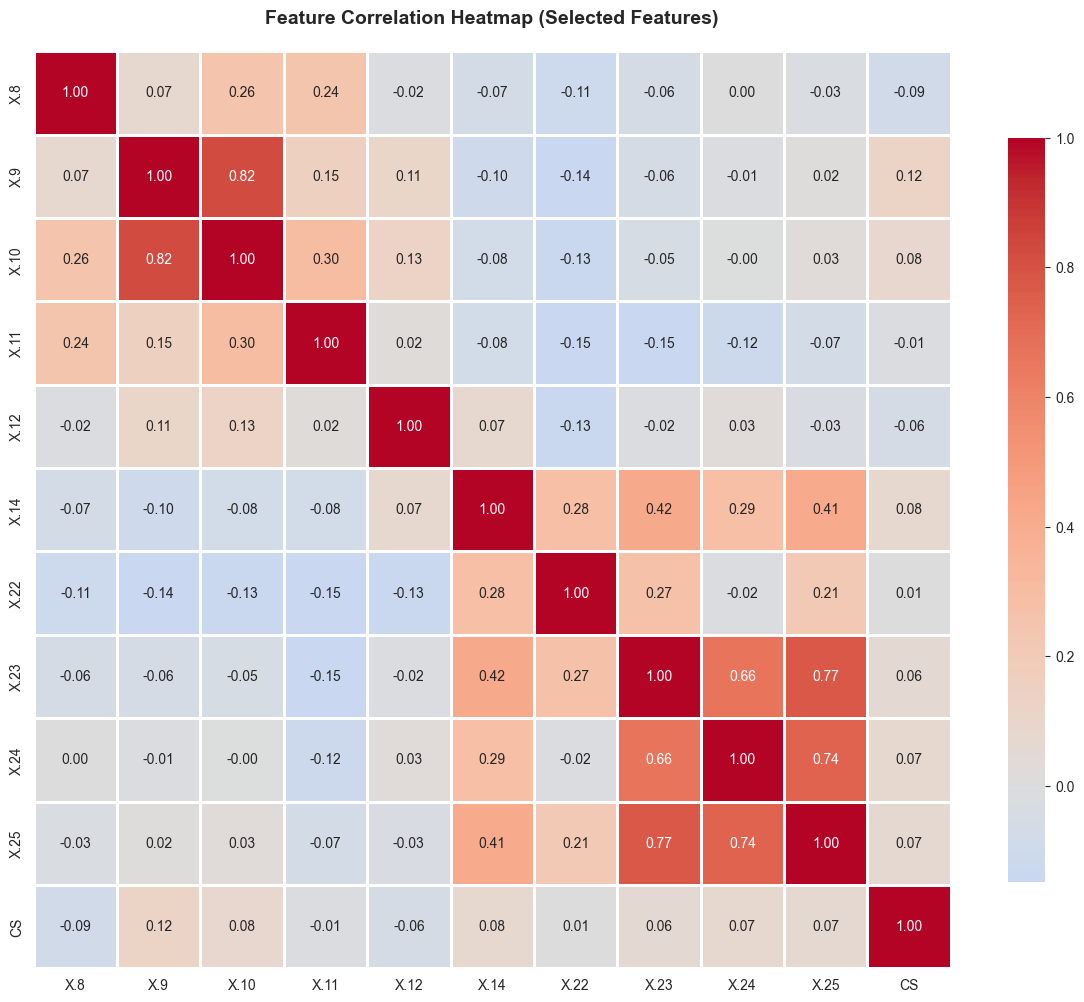

In [6]:
# Identify numerical features
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['X.1', 'X.15', 'X.16', 'X.17', 'X.18', 'CS', 'LC', 'HALC']
numeric_features = [col for col in numeric_features if col not in exclude_cols]

print(f"Numerical features: {len(numeric_features)}")
print(numeric_features[:10])  # Show first 10

# Correlation heatmap for selected features
key_features = ['X.8', 'X.9', 'X.10', 'X.11', 'X.12', 'X.14', 'X.22', 'X.23', 'X.24', 'X.25', 'CS']
correlation_matrix = train_df[key_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Selected Features)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 3.2 Categorical Features

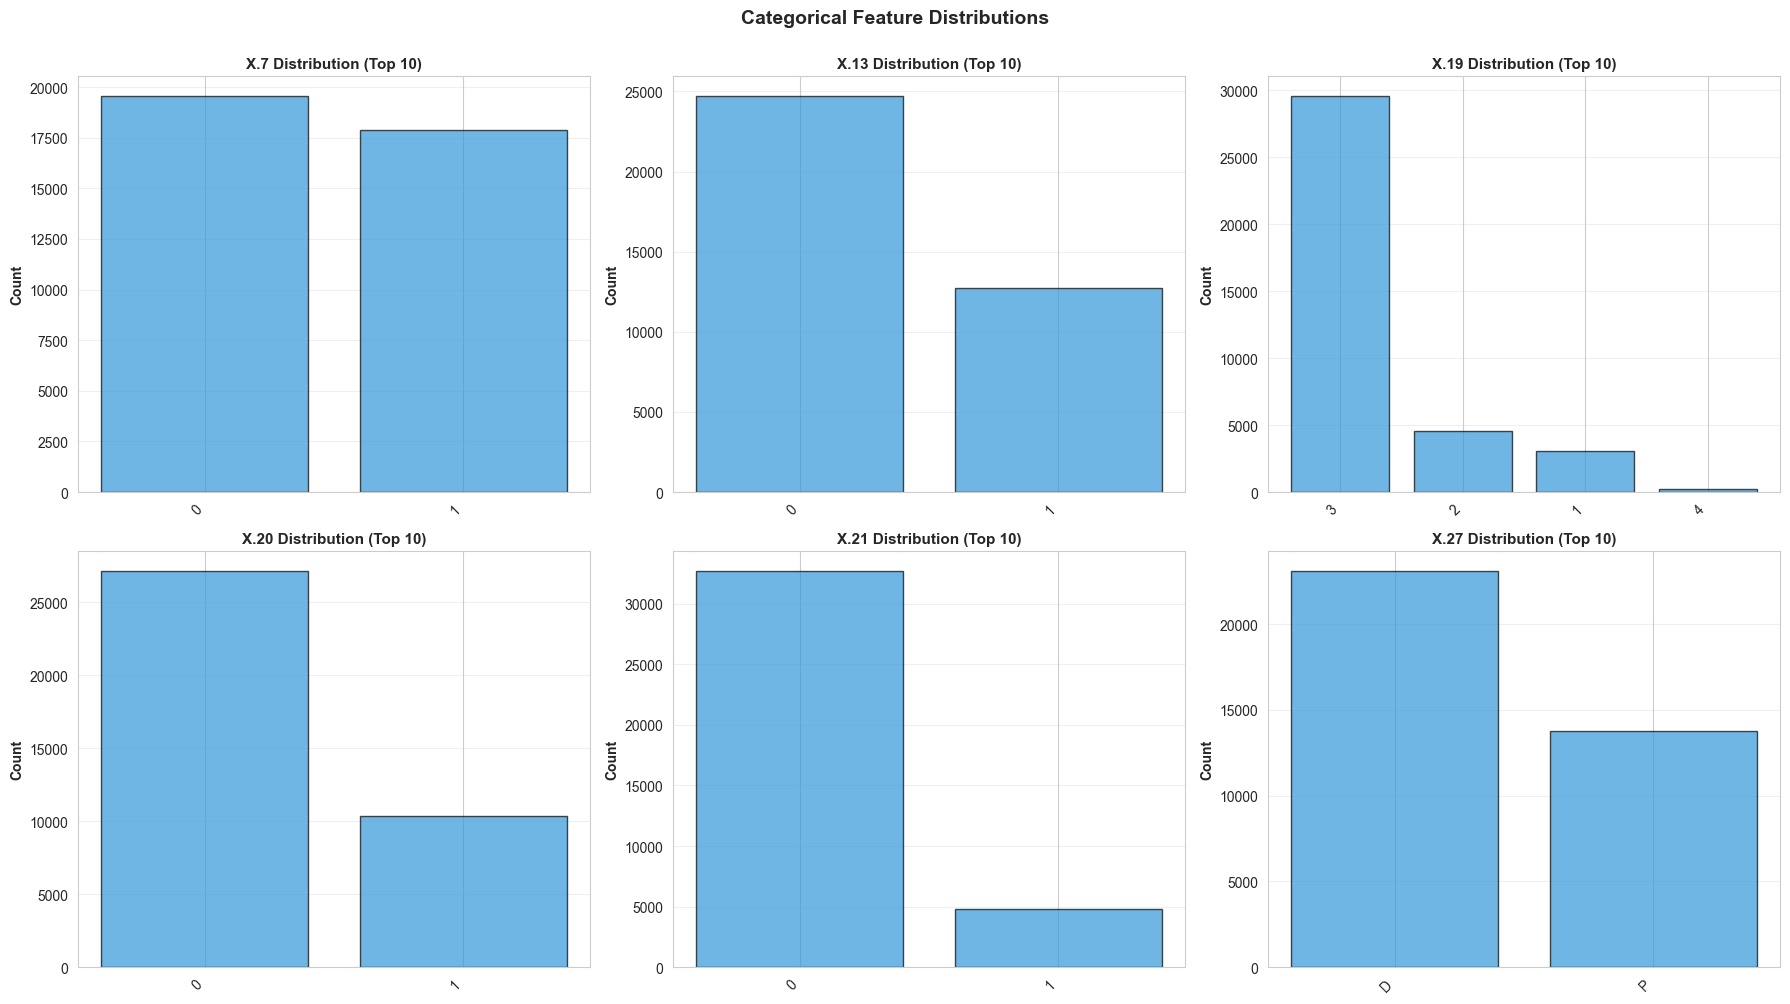

In [7]:
# Analyze categorical features
categorical_features = ['X.7', 'X.13', 'X.19', 'X.20', 'X.21', 'X.27']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    value_counts = train_df[col].value_counts().head(10)
    axes[idx].bar(range(len(value_counts)), value_counts.values, color='#3498db', edgecolor='black', alpha=0.7)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_ylabel('Count', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{col} Distribution (Top 10)', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.3 Date Features Analysis

In [8]:
# Analyze date features
date_features = ['X.2', 'X.3', 'X.4', 'X.5', 'X.6']

print("Date Features Analysis:")
for col in date_features:
    if col in train_df.columns:
        print(f"\n{col}:")
        print(f"  Min: {train_df[col].min()}")
        print(f"  Max: {train_df[col].max()}")
        print(f"  Missing: {train_df[col].isna().sum()}")

print("\n[INSIGHT] Date features can be transformed into:")
print("  - Driver age (from birth date)")
print("  - Driver experience (from license date)")
print("  - Policy duration")
print("  - Vehicle age")

Date Features Analysis:

X.2:
  Min: 01/01/2007
  Max: 31/12/2017
  Missing: 0

X.3:
  Min: 01/01/2016
  Max: 31/12/2017
  Missing: 0

X.4:
  Min: 01/01/2017
  Max: 31/12/2018
  Missing: 0

X.5:
  Min: 1918-04-05 00:00:00
  Max: 2000-10-11 00:00:00
  Missing: 0

X.6:
  Min: 1942-10-01 00:00:00
  Max: 2018-11-26 00:00:00
  Missing: 0

[INSIGHT] Date features can be transformed into:
  - Driver age (from birth date)
  - Driver experience (from license date)
  - Policy duration
  - Vehicle age


## 4. Missing Values Analysis

Columns with Missing Values:
      Missing_Count  Percentage
X.27            593    1.583402


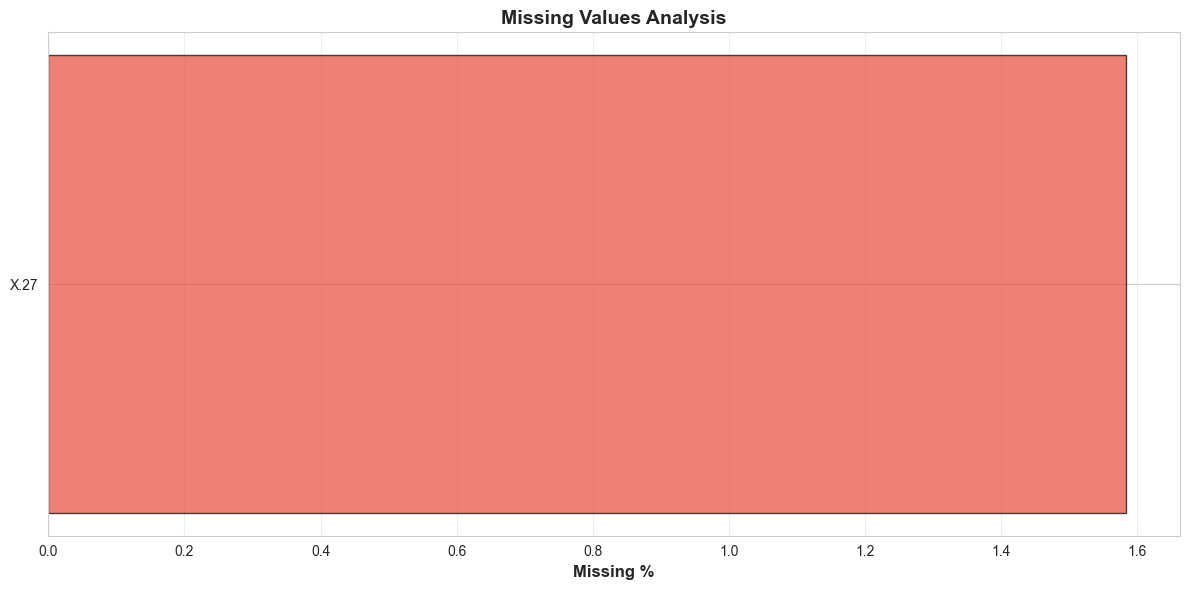

In [9]:
# Check missing values
missing_data = train_df.isnull().sum()
missing_pct = (missing_data / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_pct
}).sort_values('Missing_Count', ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0]

if len(missing_df) > 0:
    print("Columns with Missing Values:")
    print(missing_df)
    
    # Visualize
    if len(missing_df) <= 20:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.barh(range(len(missing_df)), missing_df['Percentage'], color='#e74c3c', edgecolor='black', alpha=0.7)
        ax.set_yticks(range(len(missing_df)))
        ax.set_yticklabels(missing_df.index)
        ax.set_xlabel('Missing %', fontsize=12, fontweight='bold')
        ax.set_title('Missing Values Analysis', fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No missing values in the dataset!")

## 5. Key Insights Summary

### Data Characteristics:
1. **Severe Class Imbalance**: ~89% of records have no claims
2. **Zero-Inflated Targets**: LC and HALC have ~89% zeros
3. **Tweedie Distribution**: Perfect fit for insurance claims modeling

### Modeling Implications:
1. Use **stratified sampling** for cross-validation
2. Consider **two approaches**:
   - Approach A: Two-stage (classification + regression on claims)
   - Approach B: Direct Tweedie regression (handles zeros naturally)
3. **Feature engineering** needed for date variables

### Next Steps:
- Feature engineering (Notebook 02)
- Classification modeling (Notebook 03)
- Regression modeling (Notebook 04)
- Approach comparison (Notebook 05)